# Advection: CFL, Conservation, and Transport Quality
### Fixed-mesh transport experiment: upwind versus Lax-Wendroff

**Learning goal:** Explain and demonstrate how CFL number and flux choice independently affect stability, mass conservation, positivity, diffusion, and oscillations.

**Targets:** Stable-case mass drift below 1e-12, upwind bounds and total variation preserved at CFL <= 1, both methods reduce to a cyclic shift at CFL = 1, and CFL = 1.25 produces detectable growth for the top-hat case.

**Notation:** q_i is a cell average, N is the number of cells, dx = 1/N, a = 1, C = a dt/dx. No duplicated endpoint is stored.

## 1. Governing model and reference solution

Transport a passive scalar around a periodic unit ring:
$$q_t+(aq)_x=0,\qquad a=1,\quad x\in[0,1),\quad q(x+1,t)=q(x,t).$$
The exact solution is $q(x,t)=q_0((x-at)\bmod1)$.

Use **N = 200 cells** for every main run, with edges x_j = j/N and centers x_i = (i+1/2)/N. Test:
1. Smooth signal: $q_0(x)=1+0.2\sin(2\pi x)$.
2. Top hat: $q_0(x)=1$ for $0.2\leq x<0.4$, and zero elsewhere.

Store true cell averages. For the sine signal, derive the cell integral analytically (the sine amplitude is multiplied by sinc(dx), with NumPy's normalized sinc convention). The top-hat edges align with this mesh, so its initial cell averages are exactly zero or one.

Run to T = 1, one complete transit around the ring. The exact final cell-average vector equals the initial vector. If an unstable run terminates early, do not compare its vector with the T = 1 reference. Record the actual stop time and reason.

Before implementation, predict which method will be bounded, diffusive, oscillatory, or unstable for C in {0.5, 1.0, 1.25}.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

N = 200
DX = 1.0 / N
A = 1.0
T_FINAL = 1.0
CFL_VALUES = (0.5, 1.0, 1.25)
PROFILE_VALUES = ("smooth", "top-hat")
BLOWUP_LIMIT = 1e6

CELL_EDGES = np.linspace(0.0, 1.0, N + 1)
CELL_CENTERS = 0.5 * (CELL_EDGES[:-1] + CELL_EDGES[1:])
cell_averages = 1.0 + 0.2 * np.sinc(DX) * np.sin(2.0 * np.pi * CELL_CENTERS)

PREDICTIONS = {
    0.5: ("Both methods should be stable; upwind is more diffusive.", "Stable"),
    1.0: ("Both methods should be stable and shift by one cell per step.", "Stable"),
    1.25: ("Both methods are outside their linear stability range.", "Unstable"),
}

parameters = {
    "N": N,
    "DX": DX,
    "A": A,
    "T_FINAL": T_FINAL,
    "CFL_VALUES": CFL_VALUES,
    "PROFILE_VALUES": PROFILE_VALUES,
    "BLOWUP_LIMIT": BLOWUP_LIMIT,
    "CELL_EDGES": CELL_EDGES,
    "CELL_CENTERS": CELL_CENTERS,
    "cell_averages": cell_averages,
    "PREDICTIONS": PREDICTIONS,
}

## 2. Discretization and conditions

Implement the conservative update
$$q_i^{n+1}=q_i^n-\frac{\Delta t}{\Delta x}(F_{i+1/2}-F_{i-1/2}).$$
For a > 0, compare two interface fluxes:
$$F^{\rm up}_{i+1/2}=a q_i,$$
$$F^{\rm LW}_{i+1/2}=\frac{a}{2}(q_i+q_{i+1})-\frac{a^2\Delta t}{2\Delta x}(q_{i+1}-q_i).$$
The second is the Lax-Wendroff flux. Each interface flux must be shared by the two adjacent cells. Use periodic indexing, for example `np.roll`, with no ghost endpoint duplication.

**Tasks:** Implement separate flux and stepping functions. Use old-state arrays when calculating the full flux vector; avoid updating cells in place. Show on paper why the flux differences telescope in the global sum. Derive the update weights and explain the upwind convex-combination condition.

Use dt = C dx/a, with a shortened final step only if necessary to hit T exactly. Log the actual CFL and use the actual dt in the Lax-Wendroff flux. The specified cases divide T into an integer number of nominal steps, apart from floating-point roundoff.

For runs exceeding max(abs(q)) = 1e6, or producing nonfinite values, stop deliberately and record the failure. Retain the finite history up to that point. This guard protects the experiment; it is not a limiter or a stability fix.

In [2]:
def set_up_initial_conditions(cell_edges, profile):
    """Return exact cell averages for a smooth sine wave or aligned top hat."""
    dx = cell_edges[1] - cell_edges[0]
    centers = 0.5 * (cell_edges[:-1] + cell_edges[1:])

    if profile == "smooth":
        return 1.0 + 0.2 * np.sinc(dx) * np.sin(2.0 * np.pi * centers)
    if profile == "top-hat":
        overlap = np.maximum(
            0.0,
            np.minimum(cell_edges[1:], 0.4) - np.maximum(cell_edges[:-1], 0.2),
        )
        return overlap / dx
    raise ValueError(f"Unknown profile: {profile}")


def interface_flux(q, a, dt, dx, method):
    """Return fluxes at each cell's right face, using periodic neighbors."""
    q_right = np.roll(q, -1)
    if method == "upwind":
        return a * q
    if method == "lax-wendroff":
        return 0.5 * a * (q + q_right) - 0.5 * a**2 * dt / dx * (q_right - q)
    raise ValueError(f"Unknown method: {method}")


def step(q, a, dt, dx, method):
    """Advance one conservative, fully discrete finite-volume step."""
    flux = interface_flux(q, a, dt, dx, method)
    return q - (dt / dx) * (flux - np.roll(flux, 1))


def total_variation(q):
    """Return periodic total variation, including the last-to-first jump."""
    return float(np.sum(np.abs(np.roll(q, -1) - q)))


def solve_problem(parameters, method, profile):
    """Run one profile/method/CFL case and retain finite states and diagnostics."""
    dx = parameters["DX"]
    a = parameters["A"]
    final_time = parameters["T_FINAL"]
    nominal_dt = parameters["CFL"] * dx / a
    q_initial = set_up_initial_conditions(parameters["CELL_EDGES"], profile)
    q = q_initial.copy()

    times = [0.0]
    states = [q.copy()]
    masses = [float(np.sum(q) * dx)]
    min_q = [float(np.min(q))]
    max_q = [float(np.max(q))]
    total_variations = [total_variation(q)]
    actual_cfl = []
    stop_reason = "Reached final time"

    while times[-1] < final_time:
        dt = min(nominal_dt, final_time - times[-1])
        q_new = step(q, a, dt, dx, method)

        if not np.all(np.isfinite(q_new)):
            stop_reason = "Nonfinite value"
            break

        q = q_new
        times.append(times[-1] + dt)
        states.append(q.copy())
        masses.append(float(np.sum(q) * dx))
        min_q.append(float(np.min(q)))
        max_q.append(float(np.max(q)))
        total_variations.append(total_variation(q))
        actual_cfl.append(a * dt / dx)

        if np.max(np.abs(q)) > parameters["BLOWUP_LIMIT"]:
            stop_reason = "Blow-up guard triggered"
            break

    return {
        "q_initial": q_initial,
        "q_final": q.copy(),
        "times": np.asarray(times),
        "states": states,
        "mass": np.asarray(masses),
        "min_q": np.asarray(min_q),
        "max_q": np.asarray(max_q),
        "tv": np.asarray(total_variations),
        "actual_cfl": np.asarray(actual_cfl),
        "stop_reason": stop_reason,
        "completed": times[-1] >= final_time,
    }

## 3. Error measures and expected behavior

The core diagnostics are physical and discrete properties, not mesh-refinement rates:
$$M=\Delta x\sum_iq_i,\qquad
TV=\sum_i|q_{i+1}-q_i|,\qquad
A_{\rm range}=\max_iq_i-\min_iq_i.$$
Include the last-to-first periodic jump in TV. Track mass drift relative to the initial mass. For the smooth signal, track Fourier-mode amplitude with
$$A_1=\frac{2}{N}\left|\sum_i(q_i-\bar q)e^{-2\pi\mathrm{i}x_i}\right|.$$
Use A1(T)/A1(0) to quantify damping without confusing a change of phase with a change of amplitude.

For the top hat, record undershoot max(0,-min(q)) and overshoot max(0,max(q)-1). A conservative method need not preserve bounds, and boundedness is not the same as nondiffusive transport.

**Predict and check:** Upwind at C = 0.5 smears a discontinuity. Lax-Wendroff can maintain smooth signal amplitude better but ring near discontinuities. At C = 1 both schemes shift exactly one cell per step. C = 1.25 lies outside their linear stability ranges for this equation. The top hat excites short-wave content needed to expose instability; a smooth low-frequency signal may hide it over a short run.

Optional final-return discrepancy may be reported, but it is not the learning objective. Do not compute Richardson extrapolation, GCI, or mesh-convergence orders.

In [3]:
METHOD_VALUES = ("upwind", "lax-wendroff")
results = {}

for profile in PROFILE_VALUES:
    results[profile] = {}
    for method in METHOD_VALUES:
        results[profile][method] = {}
        for cfl in CFL_VALUES:
            case_parameters = parameters.copy()
            case_parameters["CFL"] = cfl
            run = solve_problem(case_parameters, method, profile)
            run["requested_cfl"] = cfl
            results[profile][method][cfl] = run

results_upwind = {
    profile: results[profile]["upwind"] for profile in PROFILE_VALUES
}
results_lw = {
    profile: results[profile]["lax-wendroff"] for profile in PROFILE_VALUES
}

for profile in PROFILE_VALUES:
    print(f"Completed {profile} profile runs.")

Completed smooth profile runs.
Completed top-hat profile runs.


## 4. Results and diagnostics

Display one table with profile, method, requested CFL, expected stability behavior, actual terminal time, stop reason, maximum mass drift, initial/final TV, min/max values, and smooth-signal amplitude ratio when applicable.

Explain which stable case is most diffusive and which creates new extrema. Record whether the unstable top-hat runs trigger the guard or finish with substantial amplification. Do not interpret tiny relative mass drift after catastrophic growth as useful accuracy.

In [5]:
def first_mode_amplitude(q, cell_centers):
    centered_q = q - np.mean(q)
    mode = np.exp(-2j * np.pi * cell_centers)
    return float(2.0 / len(q) * np.abs(np.sum(centered_q * mode)))


table = [
    "| Profile | Method | CFL | Expected | End time | Stop reason | Max mass drift | TV initial/final | Min / max | A1 ratio |",
    "|---|---|---:|---|---:|---|---:|---:|---:|---:|",
]

for profile in PROFILE_VALUES:
    for method in METHOD_VALUES:
        for cfl in CFL_VALUES:
            run = results[profile][method][cfl]
            expected = parameters["PREDICTIONS"][cfl][1]
            mass_drift = np.max(np.abs(run["mass"] - run["mass"][0]))
            tv_pair = f"{run['tv'][0]:.6g} / {run['tv'][-1]:.6g}"
            bounds = f"{run['min_q'][-1]:.6g} / {run['max_q'][-1]:.6g}"
            if profile == "smooth":
                amplitude_ratio = first_mode_amplitude(
                    run["q_final"], CELL_CENTERS
                ) / first_mode_amplitude(run["q_initial"], CELL_CENTERS)
                amplitude_text = f"{amplitude_ratio:.6g}"
            else:
                amplitude_text = "N/A"
            table.append(
                f"| {profile} | {method} | {cfl:g} | {expected} | {run['times'][-1]:.6g} "
                f"| {run['stop_reason']} | {mass_drift:.3e} | {tv_pair} "
                f"| {bounds} | {amplitude_text} |"
            )

display(Markdown("\n".join(table)))

| Profile | Method | CFL | Expected | End time | Stop reason | Max mass drift | TV initial/final | Min / max | A1 ratio |
|---|---|---:|---|---:|---|---:|---:|---:|---:|
| smooth | upwind | 0.5 | Stable | 1 | Reached final time | 2.220e-16 | 0.799868 / 0.761353 | 0.809662 / 1.19034 | 0.951848 |
| smooth | upwind | 1 | Stable | 1 | Reached final time | 2.220e-16 | 0.799868 / 0.799868 | 0.800033 / 1.19997 | 1 |
| smooth | upwind | 1.25 | Unstable | 0.7875 | Blow-up guard triggered | 6.985e-12 | 0.799868 / 1.61976e+08 | -1.12234e+06 / 1.12741e+06 | 1.01962 |
| smooth | lax-wendroff | 0.5 | Stable | 1 | Reached final time | 2.220e-16 | 0.799868 / 0.799871 | 0.800032 / 1.19997 | 0.999991 |
| smooth | lax-wendroff | 1 | Stable | 1 | Reached final time | 2.220e-16 | 0.799868 / 0.799868 | 0.800033 / 1.19997 | 1 |
| smooth | lax-wendroff | 1.25 | Unstable | 0.425 | Blow-up guard triggered | 5.530e-12 | 0.799868 / 2.11279e+08 | -1.44274e+06 / 1.44349e+06 | 1.00001 |
| top-hat | upwind | 0.5 | Stable | 1 | Reached final time | 5.551e-17 | 2 / 1.90873 | 5.45612e-16 / 0.954365 | N/A |
| top-hat | upwind | 1 | Stable | 1 | Reached final time | 2.776e-17 | 2 / 2 | 0 / 1 | N/A |
| top-hat | upwind | 1.25 | Unstable | 0.25625 | Blow-up guard triggered | 3.492e-12 | 2 / 3.3172e+07 | -1.41354e+06 / 1.41354e+06 | N/A |
| top-hat | lax-wendroff | 0.5 | Stable | 1 | Reached final time | 1.110e-16 | 2 / 3.84704 | -0.231319 / 1.23206 | N/A |
| top-hat | lax-wendroff | 1 | Stable | 1 | Reached final time | 2.776e-17 | 2 / 2 | -7.72715e-14 / 1 | N/A |
| top-hat | lax-wendroff | 1.25 | Unstable | 0.1375 | Blow-up guard triggered | 2.619e-12 | 2 / 3.18366e+07 | -1.09569e+06 / 1.09569e+06 | N/A |

## 5. Solution and diagnostic plots

Create three static figures:
1. Smooth final profiles for both methods at C = 0.5 and 1.0, over the exact final cell averages.
2. Top-hat final profiles for both methods at C = 0.5 and 1.0; zoom near an edge to distinguish diffusion from ringing.
3. Time histories of mass drift, total variation, and max(abs(q)) for top-hat cases including C = 1.25. Use a logarithmic vertical scale for amplification where appropriate.

The interactive explorer below lets you select the profile, method, and CFL to inspect the final solution and its diagnostic histories. Unstable histories stop at their actual recorded times. The static figures remain available for side-by-side comparison.

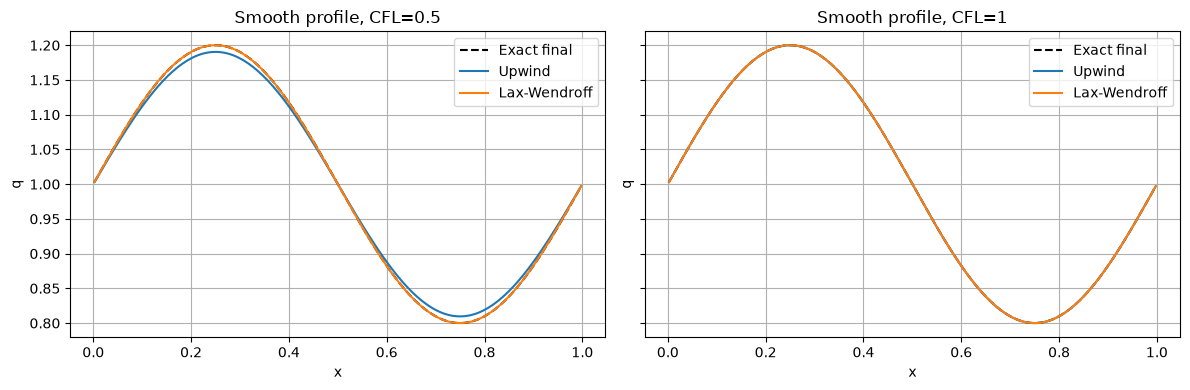

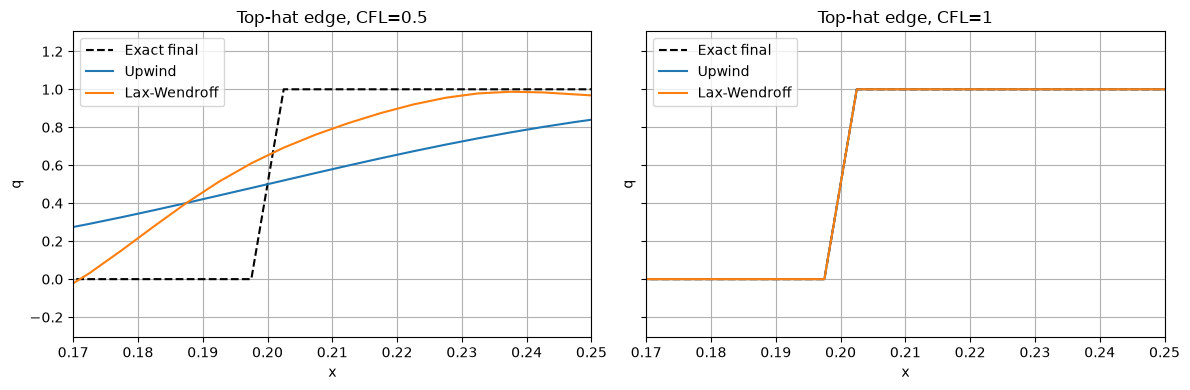

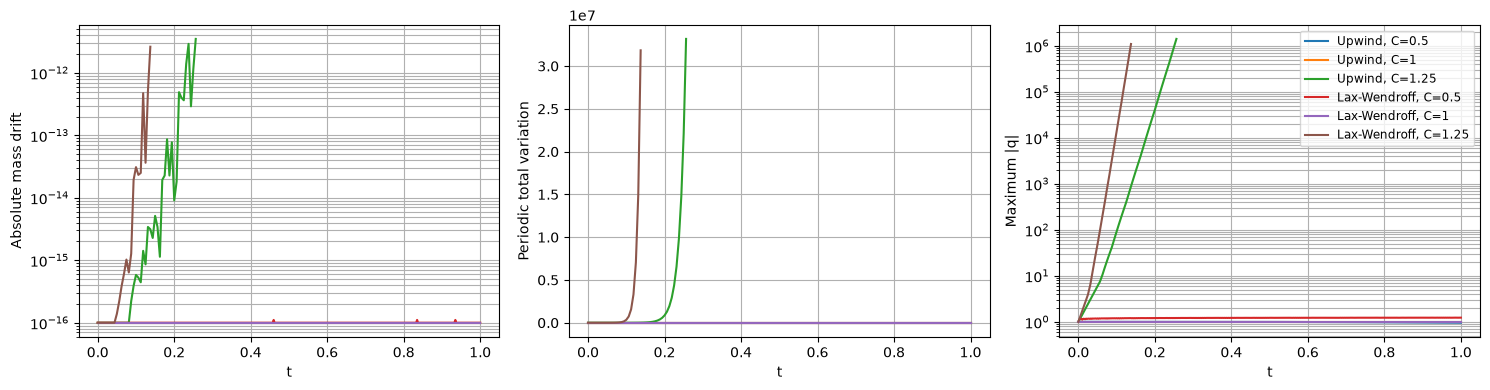

In [6]:
smooth_initial = set_up_initial_conditions(CELL_EDGES, "smooth")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, cfl in zip(axes, (0.5, 1.0)):
    ax.plot(CELL_CENTERS, smooth_initial, "k--", label="Exact final")
    for method, label in (("upwind", "Upwind"), ("lax-wendroff", "Lax-Wendroff")):
        run = results["smooth"][method][cfl]
        ax.plot(CELL_CENTERS, run["q_final"], label=label)
    ax.set(title=f"Smooth profile, CFL={cfl:g}", xlabel="x", ylabel="q")
    ax.grid(True)
    ax.legend()
fig.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
top_hat_initial = set_up_initial_conditions(CELL_EDGES, "top-hat")
for ax, cfl in zip(axes, (0.5, 1.0)):
    ax.plot(CELL_CENTERS, top_hat_initial, "k--", label="Exact final")
    for method, label in (("upwind", "Upwind"), ("lax-wendroff", "Lax-Wendroff")):
        run = results["top-hat"][method][cfl]
        ax.plot(CELL_CENTERS, run["q_final"], label=label)
    ax.set(xlim=(0.17, 0.25), title=f"Top-hat edge, CFL={cfl:g}", xlabel="x", ylabel="q")
    ax.grid(True)
    ax.legend()
fig.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, label in (("upwind", "Upwind"), ("lax-wendroff", "Lax-Wendroff")):
    for cfl in CFL_VALUES:
        run = results["top-hat"][method][cfl]
        times = run["times"]
        mass_drift = np.abs(run["mass"] - run["mass"][0])
        max_amplitude = np.asarray([np.max(np.abs(state)) for state in run["states"]])
        series_label = f"{label}, C={cfl:g}"
        axes[0].plot(times, np.maximum(mass_drift, 1e-16), label=series_label)
        axes[1].plot(times, run["tv"], label=series_label)
        axes[2].plot(times, max_amplitude, label=series_label)
axes[0].set_yscale("log")
axes[2].set_yscale("log")
for ax, ylabel in zip(axes, ("Absolute mass drift", "Periodic total variation", "Maximum |q|")):
    ax.set(xlabel="t", ylabel=ylabel)
    ax.grid(True, which="both")
axes[2].legend(fontsize="small")
fig.tight_layout()

In [8]:
import ipywidgets as widgets


def plot_interactive_case(profile, method, cfl):
    run = results[profile][method][cfl]
    times = run["times"]
    mass_drift = np.abs(run["mass"] - run["mass"][0])
    max_amplitude = np.asarray(
        [np.max(np.abs(state)) for state in run["states"]]
    )
    method_label = "Upwind" if method == "upwind" else "Lax-Wendroff"
    completion = "final time" if run["completed"] else f"stopped at t={times[-1]:.5g}"

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    profile_ax, mass_ax, tv_ax, amplitude_ax = axes.flat
    profile_ax.plot(
        CELL_CENTERS, run["q_initial"], "k--", label="Initial / exact final"
    )
    profile_ax.plot(CELL_CENTERS, run["q_final"], label="Computed")
    if not run["completed"]:
        profile_ax.set_yscale("symlog", linthresh=1.0)
    profile_ax.set(
        title=f"{profile}: {method_label}, CFL={cfl:g} ({completion})",
        xlabel="x",
        ylabel="q",
    )
    profile_ax.legend()

    mass_ax.semilogy(times, np.maximum(mass_drift, 1e-16))
    mass_ax.set(title="Absolute mass drift", xlabel="t", ylabel="|M(t) - M(0)|")
    tv_ax.plot(times, run["tv"])
    tv_ax.set(title="Periodic total variation", xlabel="t", ylabel="TV")
    amplitude_ax.semilogy(times, max_amplitude)
    amplitude_ax.set(title="Maximum amplitude", xlabel="t", ylabel="max |q|")

    for ax in axes.flat:
        ax.grid(True, which="both")
    fig.tight_layout()
    display(fig)
    plt.close(fig)


profile_control = widgets.Dropdown(
    options=(("Smooth sine", "smooth"), ("Top hat", "top-hat")),
    value="smooth",
    description="Profile",
)
method_control = widgets.ToggleButtons(
    options=(("Upwind", "upwind"), ("Lax-Wendroff", "lax-wendroff")),
    value="upwind",
    description="Method",
)
cfl_control = widgets.SelectionSlider(
    options=CFL_VALUES,
    value=0.5,
    description="CFL",
    continuous_update=False,
)
interactive_plot = widgets.interactive_output(
    plot_interactive_case,
    {"profile": profile_control, "method": method_control, "cfl": cfl_control},
)
display(
    widgets.VBox(
        [
            widgets.HBox([profile_control, method_control, cfl_control]),
            interactive_plot,
        ]
    )
)

## 6. Automatic checks

Test properties with evidence independent of the flux implementation:
- A constant field survives one step to absolute tolerance 1e-14.
- At C = 1, both methods match a cyclic shift of an arbitrary vector to 1e-13 in one step.
- Every stable run (C <= 1) preserves mass to absolute drift <= 1e-12.
- For upwind C <= 1, bounds remain within the initial bounds plus tolerance 1e-12, and TV never exceeds its initial value by more than 1e-10.
- At C = 1 and T = 1, both final states match initial states to 1e-11.
- Each top-hat run at C = 1.25 triggers the guard or has maximum amplitude at least ten times its initial maximum by T = 1.

Do not impose positivity or TVD checks on Lax-Wendroff as though they were guaranteed properties. Do not assert mass tolerance after catastrophic growth: cancellation and roundoff can dominate then.

In [7]:
tolerance = 1e-12
constant = np.full(N, 3.25)
for method in METHOD_VALUES:
    for cfl in CFL_VALUES:
        dt = cfl * DX / A
        constant_next = step(constant, A, dt, DX, method)
        assert np.allclose(constant_next, constant, atol=1e-14, rtol=0.0)

random_state = np.random.default_rng(42).normal(size=N)
for method in METHOD_VALUES:
    shifted = step(random_state, A, DX / A, DX, method)
    assert np.allclose(shifted, np.roll(random_state, 1), atol=1e-13, rtol=0.0)

for profile in PROFILE_VALUES:
    for method in METHOD_VALUES:
        for cfl in (0.5, 1.0):
            run = results[profile][method][cfl]
            mass_drift = np.max(np.abs(run["mass"] - run["mass"][0]))
            assert run["completed"]
            assert mass_drift <= tolerance

        upwind_initial = results[profile]["upwind"][0.5]["q_initial"]
        initial_min = np.min(upwind_initial)
        initial_max = np.max(upwind_initial)
        for cfl in (0.5, 1.0):
            run = results[profile]["upwind"][cfl]
            assert np.min(run["min_q"]) >= initial_min - tolerance
            assert np.max(run["max_q"]) <= initial_max + tolerance
            assert np.max(run["tv"]) <= run["tv"][0] + 1e-10

for method in METHOD_VALUES:
    run = results["smooth"][method][1.0]
    assert np.allclose(run["q_final"], run["q_initial"], atol=1e-11, rtol=0.0)
    run = results["top-hat"][method][1.0]
    assert np.allclose(run["q_final"], run["q_initial"], atol=1e-11, rtol=0.0)

for method in METHOD_VALUES:
    run = results["top-hat"][method][1.25]
    initial_amplitude = np.max(np.abs(run["q_initial"]))
    max_amplitude = max(np.max(np.abs(state)) for state in run["states"])
    assert run["stop_reason"] == "Blow-up guard triggered" or max_amplitude >= 10.0 * initial_amplitude

print("All conservation, shift, bounds, TV, and unstable-case checks passed.")

All conservation, shift, bounds, TV, and unstable-case checks passed.


## 7. Discussion and next steps

Answer briefly:
1. Which experiments show that conservation, positivity, and stability are separate properties?
2. Why can C = 1 be less diffusive than C = 0.5 for first-order upwind on this problem? Does that imply that larger timesteps are generally more accurate?
3. Why does a smooth low-frequency signal fail to reveal every unstable mode?
4. Where would you place flux evaluation, time stepping, boundary handling, and diagnostics in Titan? Identify which arrays can be reused without in-place stencil hazards.
5. What changes if the physical advection speed varies or changes sign? Explain why today's left-state flux choice is not a general Riemann solver.

### Scope and limitations

This is scalar constant-speed transport on a uniform periodic mesh. It does not establish shock robustness for nonlinear Euler flow. Higher formal order alone does not ensure nonoscillatory discontinuity transport. Vectorized periodic indexing allocates temporary arrays; tiny notebook timings would not establish HPC scalability.

### Further work

Replace forward Euler on the upwind semi-discrete operator with SSPRK(3,3). Obtain its stage equations from the paper below. At the same mesh and C = 0.5, compare TV, bounds, damping, and number of right-hand-side evaluations. Predict which properties are inherited from forward Euler and why changing the temporal method does not remove first-order spatial diffusion. Derive the stability condition for the new fully discrete scheme rather than assuming every Runge-Kutta method is SSP.

### References

- **Dedicated project reference:** Ketcheson, LeVeque, and del Razo, *Riemann Problems and Jupyter Solutions*, [Advection chapter](https://www.clawpack.org/riemann_book/html/Advection.html). Read the physical conservation law and characteristic solution; derive and implement today's interface updates yourself.
- **Technical paper:** S. Gottlieb, C.-W. Shu, and E. Tadmor (2001), *Strong Stability-Preserving High-Order Time Discretization Methods*, SIAM Review 43(1), 89-112. [DOI](https://doi.org/10.1137/S003614450036757X); [public author repository](https://drum.lib.umd.edu/items/78e24b83-01d8-4e55-935e-dc8bacaf910c). Foundational reading, not recent news. Focus on convex combinations of forward-Euler steps and the conditional nature of SSP guarantees.
